
# Data Science Internship: Week 3 Task

**Student Name:** Ashna Imtiaz

**Domain:** Data Science

**Task Assigned:** Titanic Dataset Analysis — Exploration, Visualization, and Insight Generation

### Project Overview

This project involves a comprehensive Exploratory Data Analysis (EDA) of the Titanic dataset. The goal is to inspect data integrity, analyze how demographic factors like sex and age influenced survival rates, and visualize these patterns through advanced statistical plotting techniques.

### Objectives

* **Data Inspection:** Load the Titanic dataset and perform an audit of data types and missing values.
* **Survival Analysis:** Categorize passengers into age buckets and calculate survival probabilities across gender and class.
* **Statistical Visualization:** Utilize bar charts, boxplots, and violin plots to identify trends and socio-economic influences on survival.
* **Insight Reporting:** Generate a concise report summarizing the key factors that determined passenger outcomes.

---

### Implementation Code

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [7]:
# 1. Load and Clean Data
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 2. ANALYZE SURVIVAL RATES (Step 2)
# Create age buckets for better analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 60, 100], labels=['Child', 'Young Adult', 'Adult', 'Senior'])

print("\n--- Survival Rate by Sex ---")
print(df.groupby('sex')['survived'].mean())

print("\n--- Survival Rate by Class ---")

--- Data Types ---
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
age_group      category
dtype: object

--- Missing Values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
age_group      177
dtype: int64

--- Survival Rate by Sex ---
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

--- Survival Rate by Class ---


In [15]:
print(df.groupby('pclass')['survived'].mean())

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by Class and Sex')

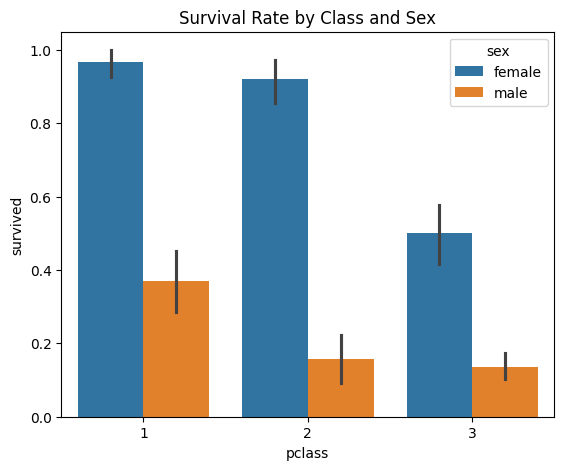

In [17]:
# 3. VISUALIZE FINDINGS (Step 3)
plt.figure(figsize=(14, 5))

# Bar Chart: Survival by Class & Sex
plt.subplot(1, 2, 1)
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival Rate by Class and Sex')

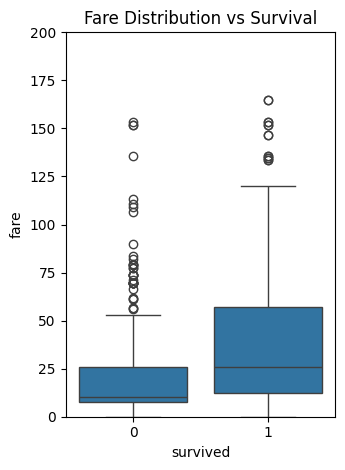

In [18]:
# Boxplot: Fare Distribution by Survival
plt.subplot(1, 2, 2)
sns.boxplot(x='survived', y='fare', data=df)
plt.ylim(0, 200) # Zoom in for clarity
plt.title('Fare Distribution vs Survival')

plt.tight_layout()
plt.show()



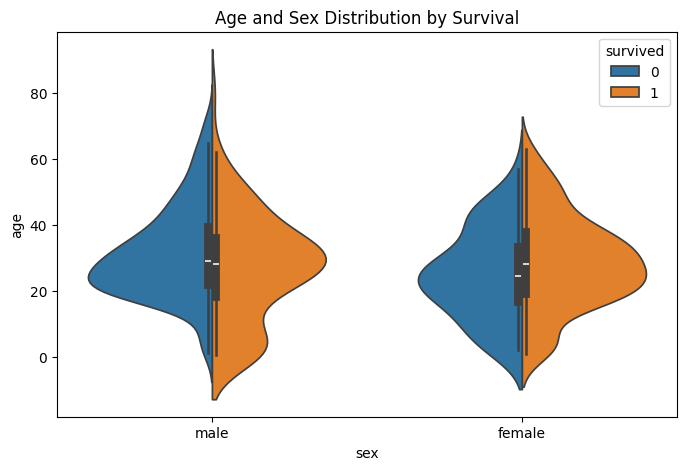

In [19]:
# Violin Plot: Age and Survival
plt.figure(figsize=(8, 5))
sns.violinplot(x='sex', y='age', hue='survived', data=df, split=True)
plt.title('Age and Sex Distribution by Survival')
plt.show()

# Train the Model

In [8]:
# Keeping Age, Pclass, and Fare; dropping rows with missing Age values
df = df[['age', 'pclass', 'fare']].dropna()

# 2. Define Features (X) and Target (y)
X = df[['age', 'pclass']]
y = df['fare']

In [10]:
# 3. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
# 5. Make Predictions
predictions = model.predict(X_test)

In [12]:
# 6. Evaluate the Model
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('R-squared:', metrics.r2_score(y_test, predictions))

MAE: 24.322781125639064
MSE: 3364.922912856981
R-squared: 0.1917633318253048


MAE: 24.322781125639064
MSE: 3364.922912856981
R-squared: 0.1917633318253048


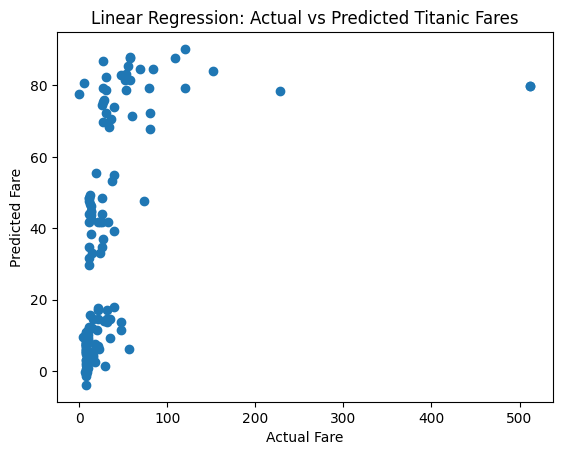

In [5]:
# 7. Visualize Predictions vs Actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Linear Regression: Actual vs Predicted Titanic Fares')
plt.show()